In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)
from sklearn.metrics import (
    classification_report,    # per-class precision, recall, F1 in one call
    confusion_matrix,         # NxN matrix of predictions vs true labels
    ConfusionMatrixDisplay,   # helper for plotting confusion matrices
)

print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Device: cuda


In [2]:
SAVE_PATH = "../models/banking77-distilbert"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Loading model from {SAVE_PATH}...")
tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
model = model.to(device)   # move model to GPU if available
model.eval()                   # put model in evaluation mode
                               # this disables dropout layers which are only
                               # used during training for regularization

# Pull label mappings directly from the saved model config
id2label = model.config.id2label   # {0: "activate_my_card", 1: "age_limit", ...}
label2id = model.config.label2id   # {"activate_my_card": 0, "age_limit": 1, ...}
num_labels = len(id2label)

print(f"Model loaded. {num_labels} classes.")

Loading model from ../models/banking77-distilbert...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded. 77 classes.


In [3]:
print("Loading and tokenizing test set...")
dataset = load_dataset("mteb/banking77")
test_data = dataset["test"]   # 3,076 examples

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

tokenized_test = test_data.map(tokenize, batched=True)
tokenized_test.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "token_type_ids"]
    # note: we keep label_text as a plain Python string for error analysis later
)

print(f"Test set ready: {len(tokenized_test)} examples")

Loading and tokenizing test set...


Map:   0%|          | 0/3076 [00:00<?, ? examples/s]

Test set ready: 3076 examples


In [4]:
BATCH_SIZE = 64
all_preds  = []
all_labels = []

print(f"Running inference on {len(tokenized_test)} test examples...")
print(f"Batch size: {BATCH_SIZE} → {len(tokenized_test) // BATCH_SIZE + 1} batches")

with torch.no_grad():
    for i in range(0, len(tokenized_test), BATCH_SIZE):
        # Slice a batch from the dataset
        batch = tokenized_test[i : i + BATCH_SIZE]

        # Move tensors to GPU/CPU and run forward pass
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)

        # Forward pass → logits shape: (batch_size, 77)
        # logits are raw scores, not probabilities yet
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        # argmax across 77 classes → predicted class index for each example
        preds = torch.argmax(outputs.logits, dim=-1)

        # .cpu().numpy() moves tensors off GPU back to CPU as numpy arrays
        # so sklearn can work with them
        all_preds.extend(preds.cpu().numpy())

        # True labels: use label2id to convert label_text strings → integers
        # We use label_text instead of the dataset's 'label' column to ensure
        # our mapping is used (same as training)
        true_labels = [
            label2id[t] for t in test_data["label_text"][i : i + BATCH_SIZE]
        ]
        all_labels.extend(true_labels)

        # Progress indicator every 10 batches
        if (i // BATCH_SIZE) % 10 == 0:
            print(f"  Processed {min(i + BATCH_SIZE, len(tokenized_test))}/{len(tokenized_test)}")

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

Running inference on 3076 test examples...
Batch size: 64 → 49 batches
  Processed 64/3076
  Processed 704/3076
  Processed 1344/3076
  Processed 1984/3076
  Processed 2624/3076


In [5]:
correct = (all_preds == all_labels).sum()
total   = len(all_labels)
print(f"\nOverall accuracy: {correct}/{total} = {correct/total:.4f}")


Overall accuracy: 2861/3076 = 0.9301


In [6]:
label_names_ordered = [id2label[i] for i in range(num_labels)]

report_str  = classification_report(all_labels, all_preds, target_names=label_names_ordered)
report_dict = classification_report(all_labels, all_preds, target_names=label_names_ordered, output_dict=True)

print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 80)
print(report_str)

PER-CLASS CLASSIFICATION REPORT
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      1.00      1.00        40
                                activate_my_card       1.00      0.97      0.99        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.97      0.97      0.97        39
                                automatic_top_up       1.00      0.93      0.96        40
         balance_not_updated_after_bank_transfer       0.80      0.82      0.81        40
balance_not_updated_after_cheque_or_cash_deposit       1.00      0.95      0.97        40
                         beneficiary_not_allowed       0.93      0.95      0.94        40
                                 cancel_transfer       0.97      0.

In [7]:
# Convert report dict to DataFrame, drop the aggregate rows
df_report = pd.DataFrame(report_dict).T
df_report = df_report.drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")
df_report = df_report.astype(float).round(4)
df_report.index.name = "class"
df_report = df_report.sort_values("f1-score", ascending=True)  # worst first

df_report.to_csv("../assets/per_class_f1.csv")
print("Saved: per_class_f1.csv")
print("\n10 WORST-PERFORMING CLASSES:")
print(df_report.head(10).to_string())
print("\n10 BEST-PERFORMING CLASSES:")
print(df_report.tail(10).to_string())

Saved: per_class_f1.csv

10 WORST-PERFORMING CLASSES:
                                         precision  recall  f1-score  support
class                                                                        
pending_transfer                            0.9032  0.7179    0.8000     39.0
balance_not_updated_after_bank_transfer     0.8049  0.8250    0.8148     40.0
topping_up_by_card                          0.8649  0.8000    0.8312     40.0
compromised_card                            0.8293  0.8500    0.8395     40.0
transfer_not_received_by_recipient          0.8095  0.8718    0.8395     39.0
why_verify_identity                         0.8889  0.8000    0.8421     40.0
verify_my_identity                          0.8140  0.8750    0.8434     40.0
card_payment_not_recognised                 0.8919  0.8250    0.8571     40.0
transfer_timing                             0.8182  0.9000    0.8571     40.0
direct_debit_payment_not_recognised         0.8718  0.8500    0.8608     40.0

10 BEST-P

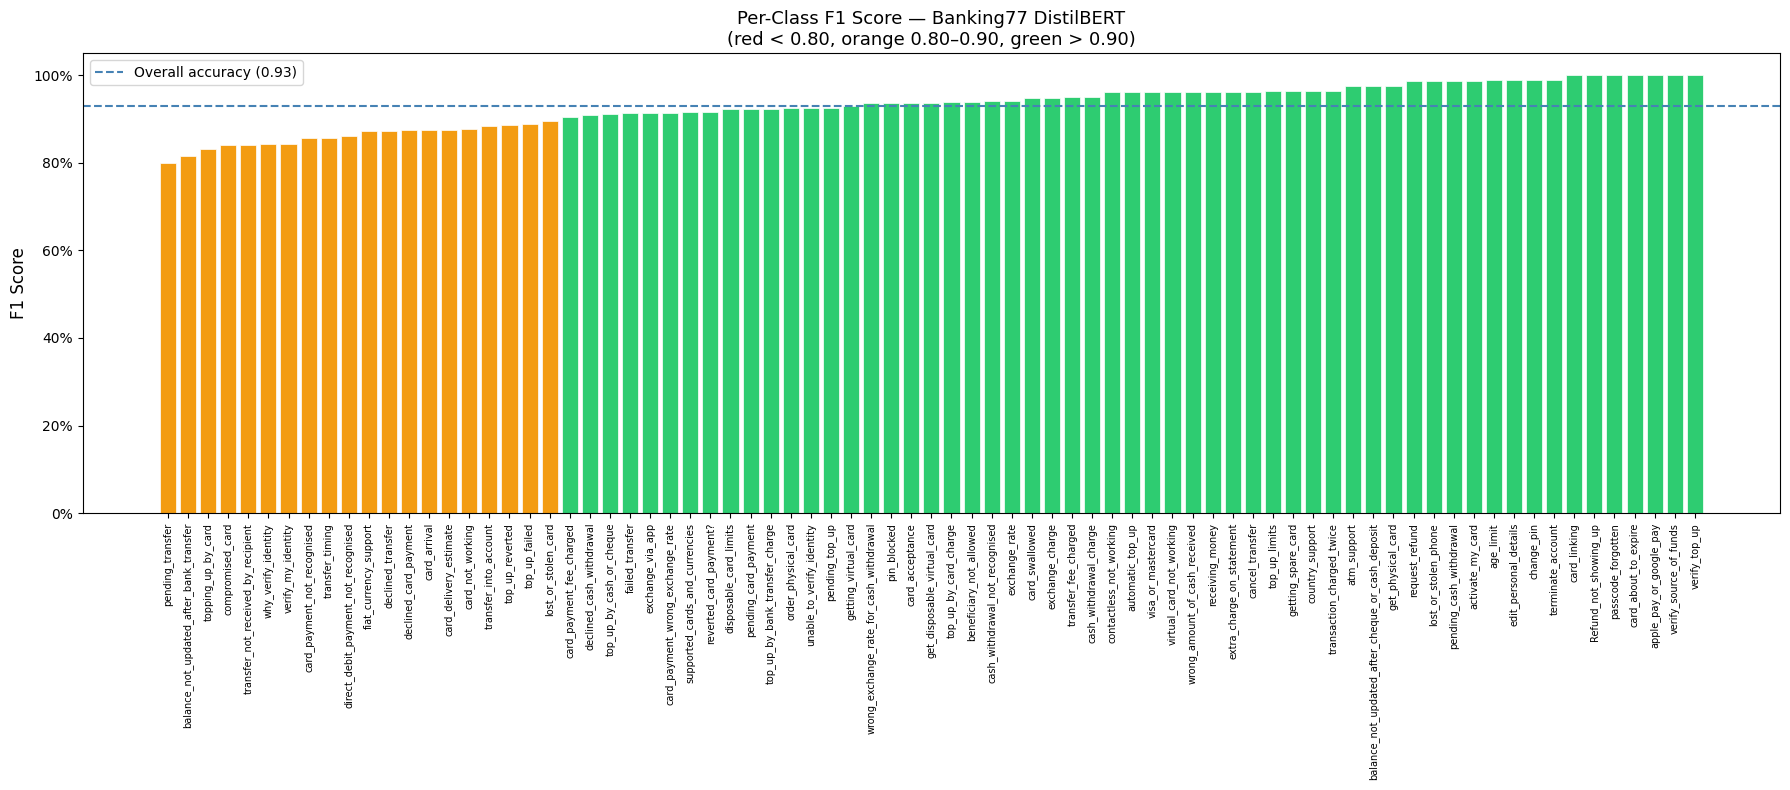

Saved: per_class_f1.png


In [8]:
df_sorted = df_report.sort_values("f1-score", ascending=True)

fig, ax = plt.subplots(figsize=(18, 8))

# Color bars by performance: red = bad, yellow = ok, green = good
colors = []
for score in df_sorted["f1-score"]:
    if score < 0.80:
        colors.append("#e74c3c")    # red
    elif score < 0.90:
        colors.append("#f39c12")    # orange
    else:
        colors.append("#2ecc71")    # green

bars = ax.bar(
    range(len(df_sorted)),
    df_sorted["f1-score"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
)

# Labels and formatting
ax.set_xticks(range(len(df_sorted)))
ax.set_xticklabels(df_sorted.index, rotation=90, fontsize=7)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Per-Class F1 Score — Banking77 DistilBERT\n(red < 0.80, orange 0.80–0.90, green > 0.90)", fontsize=13)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.93, color="steelblue", linestyle="--", linewidth=1.5, label="Overall accuracy (0.93)")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.savefig("../assets/per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: per_class_f1.png")

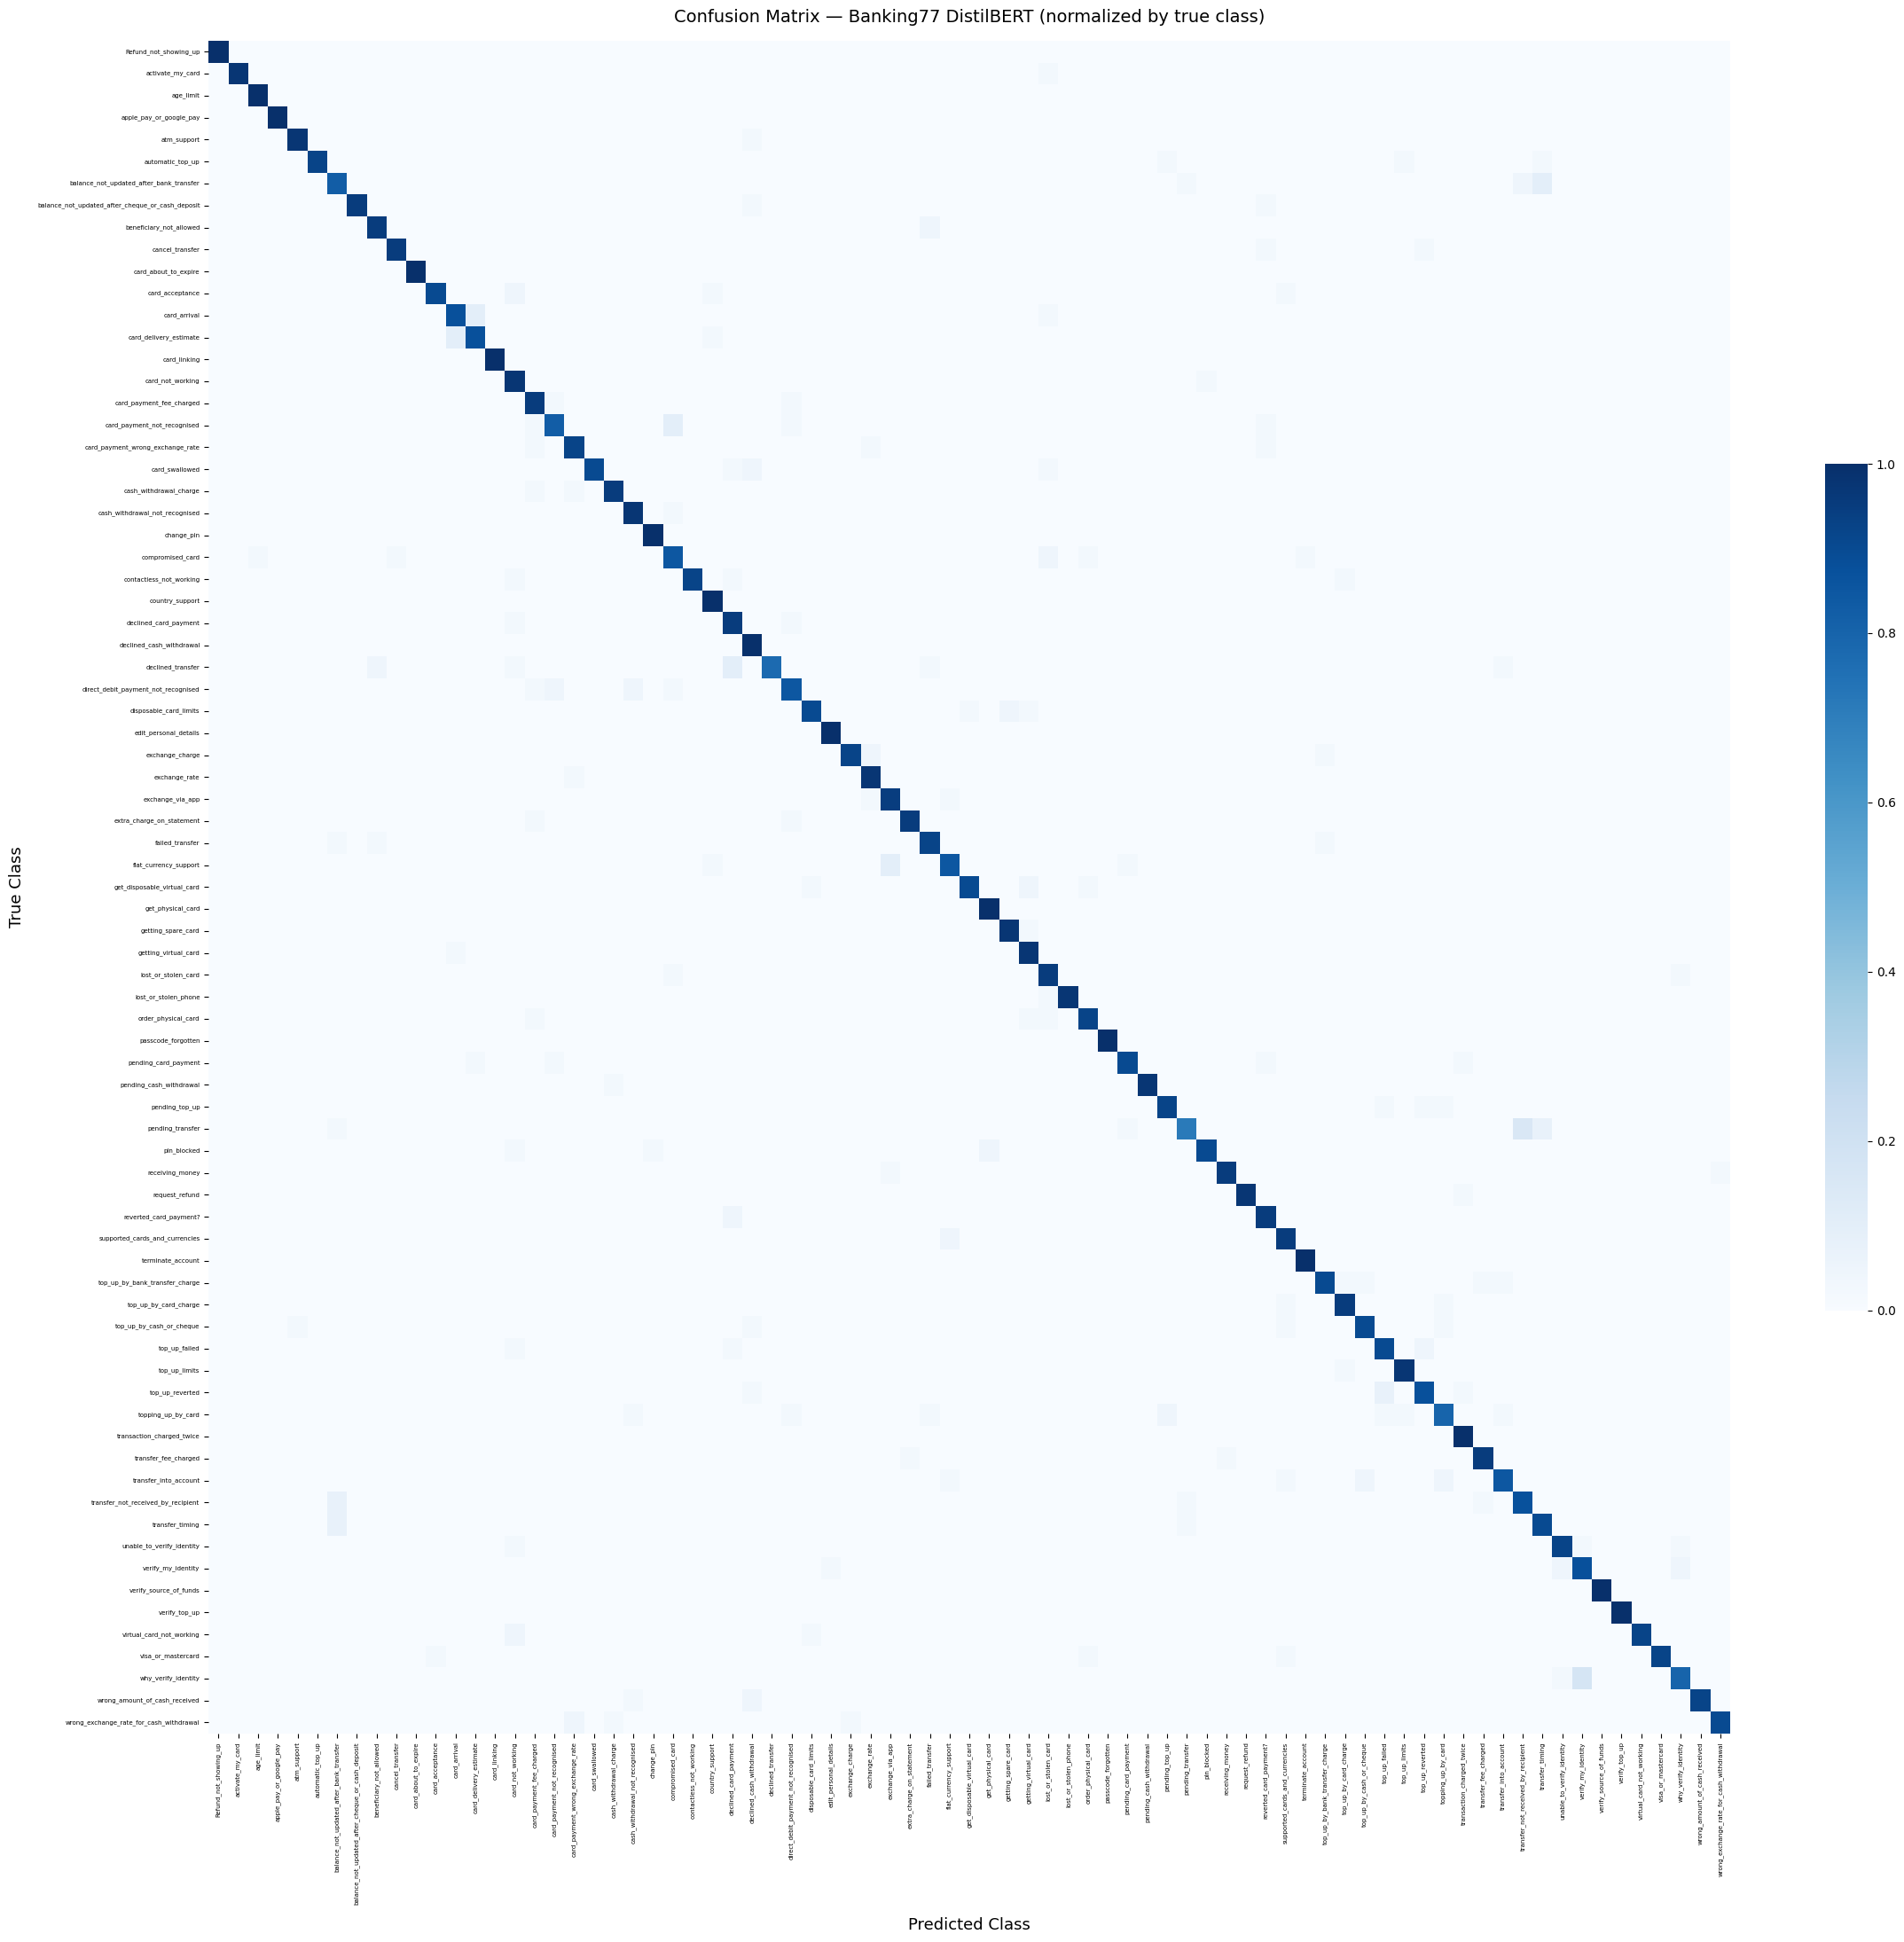

Saved: confusion_matrix.png


In [9]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, ax = plt.subplots(figsize=(24, 22))

sns.heatmap(
    cm,
    ax=ax,
    cmap="Blues",          # white = 0 (no predictions), dark blue = 1.0 (all correct)
    xticklabels=label_names_ordered,
    yticklabels=label_names_ordered,
    linewidths=0,          # no gridlines — too cluttered at 77x77
    cbar_kws={"shrink": 0.5},
)

ax.set_xlabel("Predicted Class", fontsize=13, labelpad=10)
ax.set_ylabel("True Class", fontsize=13, labelpad=10)
ax.set_title("Confusion Matrix — Banking77 DistilBERT (normalized by true class)", fontsize=14, pad=15)
ax.tick_params(axis="x", labelsize=5, rotation=90)
ax.tick_params(axis="y", labelsize=5, rotation=0)

plt.tight_layout()
plt.savefig("../assets/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

In [10]:
# Zero out the diagonal (correct predictions) so we're only looking at errors
cm_errors = confusion_matrix(all_labels, all_preds)   # raw counts this time
np.fill_diagonal(cm_errors, 0)                         # ignore correct predictions

# Find the top 15 most common confusion pairs
# unravel_index converts flat indices back to (row, col) pairs
num_top = 15
flat_indices    = np.argsort(cm_errors.ravel())[::-1][:num_top]
top_row, top_col = np.unravel_index(flat_indices, cm_errors.shape)

print(f"TOP {num_top} MOST CONFUSED CLASS PAIRS")
print("=" * 70)
print(f"{'True Class':<45} {'Predicted As':<45} {'Count':>5}")
print("-" * 70)

confusion_pairs = []
for true_idx, pred_idx in zip(top_row, top_col):
    true_name  = id2label[true_idx]
    pred_name  = id2label[pred_idx]
    count      = cm_errors[true_idx, pred_idx]
    print(f"{true_name:<45} {pred_name:<45} {count:>5}")
    confusion_pairs.append({
        "true_class":      true_name,
        "predicted_as":    pred_name,
        "count":           count,
    })

df_confusions = pd.DataFrame(confusion_pairs)


TOP 15 MOST CONFUSED CLASS PAIRS
True Class                                    Predicted As                                  Count
----------------------------------------------------------------------
why_verify_identity                           verify_my_identity                                7
pending_transfer                              transfer_not_received_by_recipient                6
fiat_currency_support                         exchange_via_app                                  4
declined_transfer                             declined_card_payment                             4
card_delivery_estimate                        card_arrival                                      4
card_payment_not_recognised                   compromised_card                                  4
balance_not_updated_after_bank_transfer       transfer_timing                                   4
card_arrival                                  card_delivery_estimate                            4
top_up_reverte

In [11]:
print("Building error analysis dataframe...")

errors = []
for i, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):
    if true_label != pred_label:
        # Get the original text and confidence for this example
        text      = test_data["text"][i]
        true_name = id2label[true_label]
        pred_name = id2label[pred_label]

        # Re-run inference on this single example to get confidence score
        # (we didn't save softmax probs during batch inference above)
        inputs  = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        probs      = torch.softmax(logits, dim=-1)[0]  # softmax → probabilities
        confidence = probs[pred_label].item()           # confidence in the wrong prediction

        errors.append({
            "text":            text,
            "true_class":      true_name,
            "predicted_as":    pred_name,
            "confidence":      round(confidence, 4),
        })

df_errors = pd.DataFrame(errors).sort_values("confidence", ascending=False)
df_errors.to_csv("../assets/error_analysis.csv", index=False)

print(f"\nTotal misclassified: {len(df_errors)} / {len(test_data)} examples")
print(f"Error rate: {len(df_errors)/len(test_data):.1%}")
print(f"\nSaved: error_analysis.csv")
print(f"\nHIGH-CONFIDENCE MISTAKES (model was wrong but very sure):")
print("=" * 80)
# High-confidence mistakes are the most interesting — the model isn't
# confused, it's systematically wrong. Usually means label ambiguity.
print(df_errors.head(15).to_string(index=False))

Building error analysis dataframe...

Total misclassified: 215 / 3076 examples
Error rate: 7.0%

Saved: error_analysis.csv

HIGH-CONFIDENCE MISTAKES (model was wrong but very sure):
                                                                                                                                                         text                              true_class                            predicted_as  confidence
                                                                                          I would like to know why my payment is still pending, can you help?                        pending_transfer                    pending_card_payment      0.9901
                                                                                                                                      My transfer is pending. balance_not_updated_after_bank_transfer                        pending_transfer      0.9883
                                                                    

In [12]:
# Grab the top confusion pair from Cell 9
top_pair      = confusion_pairs[0]
true_class    = top_pair["true_class"]
predicted_as  = top_pair["predicted_as"]

print(f"DEEP DIVE: '{true_class}' misclassified as '{predicted_as}'")
print("=" * 80)

mask = (df_errors["true_class"] == true_class) & (df_errors["predicted_as"] == predicted_as)
subset = df_errors[mask]

if len(subset) == 0:
    print("No examples found for this pair — try adjusting true_class / predicted_as")
else:
    for _, row in subset.iterrows():
        print(f"\n  Text:       \"{row['text']}\"")
        print(f"  True:        {row['true_class']}")
        print(f"  Predicted:   {row['predicted_as']}  (confidence: {row['confidence']:.1%})")

print(f"\nTotal examples of this confusion: {len(subset)}")

DEEP DIVE: 'why_verify_identity' misclassified as 'verify_my_identity'

  Text:       "What other methods are there to verify my identity?"
  True:        why_verify_identity
  Predicted:   verify_my_identity  (confidence: 96.8%)

  Text:       "What is the need to verify my identity?"
  True:        why_verify_identity
  Predicted:   verify_my_identity  (confidence: 93.0%)

  Text:       "Do I have to do the identity check?"
  True:        why_verify_identity
  Predicted:   verify_my_identity  (confidence: 77.9%)

  Text:       "Do I have to verify my identity?"
  True:        why_verify_identity
  Predicted:   verify_my_identity  (confidence: 70.9%)

  Text:       "Do I need to verify my identity?"
  True:        why_verify_identity
  Predicted:   verify_my_identity  (confidence: 59.4%)

  Text:       "Do I have to do an identity check?"
  True:        why_verify_identity
  Predicted:   verify_my_identity  (confidence: 57.0%)

  Text:       "Do I really need to verify my identity?"
 

In [13]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)

overall_acc = (all_preds == all_labels).mean()
macro_f1    = df_report["f1-score"].mean()
worst_class = df_report.index[0]
worst_f1    = df_report["f1-score"].iloc[0]
best_class  = df_report.index[-1]
best_f1     = df_report["f1-score"].iloc[-1]

print(f"\nOverall accuracy:   {overall_acc:.1%}")
print(f"Macro F1:           {macro_f1:.1%}")
print(f"\nBest class:         '{best_class}' (F1={best_f1:.2f})")
print(f"Worst class:        '{worst_class}' (F1={worst_f1:.2f})")
print(f"\nTotal errors:       {len(df_errors)} / {len(test_data)}")
print(f"\nTop confusion pair:")
print(f"  '{confusion_pairs[0]['true_class']}'")
print(f"  misclassified as '{confusion_pairs[0]['predicted_as']}'")
print(f"  {confusion_pairs[0]['count']} times")

SUMMARY

Overall accuracy:   93.0%
Macro F1:           93.0%

Best class:         'verify_top_up' (F1=1.00)
Worst class:        'pending_transfer' (F1=0.80)

Total errors:       215 / 3076

Top confusion pair:
  'why_verify_identity'
  misclassified as 'verify_my_identity'
  7 times
